# Sprint 3 – Análise Exploratória de Dados (EDA)
## ONG Saúde Bucal Solidária — Priorização de Atendimento

**Disciplina:** Artificial Intelligence e Chatbot  
**Objetivo do modelo:** Classificar se um paciente necessita de **tratamento odontológico urgente** ou não, auxiliando os gestores da ONG a priorizarem os atendimentos dos dentistas voluntários.

---

## 1. Importação de Bibliotecas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Configurações visuais
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 100,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

Matplotlib is building the font cache; this may take a moment.


## 2. Carregamento e Inspeção Inicial dos Dados

In [2]:
df = pd.read_csv("pacientes_turmadobem_dental.csv")
print(f"Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas")
df.head()

Dimensões: 500 linhas × 19 colunas


,id_paciente,idade,sexo,regiao,renda_familiar,escolaridade,ultima_consulta_anos,num_dentes_cariados,num_dentes_perdidos,dor_atual,sangramento_gengival,mobilidade_dentaria,abscesso,dificuldade_mastigar,escovacao_diaria_vezes,uso_fio_dental,fumante,diabetes,tratamento_urgente
0,PAC0001,34,Feminino,Zona Sul,Até 1 SM,Fundamental completo,8,7,3,1,1,0,0,0,0,0,0,0,1
1,PAC0002,80,Feminino,Zona Norte,Até 1 SM,Fundamental completo,7,2,2,1,0,1,0,0,2,0,0,0,1
2,PAC0003,59,Masculino,Centro,2-3 SM,Sem escolaridade,5,3,3,0,0,0,0,1,2,0,0,1,0
3,PAC0004,50,Feminino,Zona Norte,1-2 SM,Fundamental incompleto,10,3,2,1,1,0,0,0,1,0,0,0,1
4,PAC0005,19,Feminino,Zona Sul,1-2 SM,Fundamental incompleto,2,4,2,0,1,0,1,1,2,1,0,0,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   id_paciente             500 non-null    object
 1   idade                   500 non-null    int64 
 2   sexo                    500 non-null    object
 3   regiao                  500 non-null    object
 4   renda_familiar          500 non-null    object
 5   escolaridade            500 non-null    object
 6   ultima_consulta_anos    500 non-null    int64 
 7   num_dentes_cariados     500 non-null    int64 
 8   num_dentes_perdidos     500 non-null    int64 
 9   dor_atual               500 non-null    int64 
 10  sangramento_gengival    500 non-null    int64 
 11  mobilidade_dentaria     500 non-null    int64 
 12  abscesso                500 non-null    int64 
 13  dificuldade_mastigar    500 non-null    int64 
 14  escovacao_diaria_vezes  500 non-null    int64 
 15  uso_fi

In [4]:
# Verificando valores nulos
nulos = df.isnull().sum()
print("Valores nulos por coluna:")
print(nulos[nulos > 0] if nulos.sum() > 0 else "Nenhum valor nulo encontrado.")

Valores nulos por coluna:
Nenhum valor nulo encontrado.


In [5]:
df.describe()

,idade,ultima_consulta_anos,num_dentes_cariados,num_dentes_perdidos,dor_atual,sangramento_gengival,mobilidade_dentaria,abscesso,dificuldade_mastigar,escovacao_diaria_vezes,uso_fio_dental,fumante,diabetes,tratamento_urgente
count,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.00000,500.000000,500.000000,500.000000
mean,43.29600,4.946000,3.412000,1.946000,0.536000,0.488000,0.280000,0.184000,0.430000,1.76600,0.34600,0.250000,0.160000,0.550000
std,22.69128,2.864873,1.871165,1.338157,0.499202,0.500357,0.449449,0.387872,0.495572,0.91044,0.47617,0.433446,0.366973,0.497992
min,5.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000
25%,24.75000,3.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,0.00000,0.000000,0.000000,0.000000
50%,44.00000,5.000000,3.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.00000,0.00000,0.000000,0.000000,1.000000
75%,61.00000,7.000000,5.000000,3.000000,1.000000,1.000000,1.000000,0.000000,1.000000,2.00000,1.00000,0.250000,0.000000,1.000000
max,84.00000,10.000000,9.000000,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.00000,1.00000,1.000000,1.000000,1.000000


## 3. Distribuição da Variável Alvo

> **Informação observada:** Distribuição da variável alvo  
> **Categoria:** Distribuições relevantes para o problema

A variável alvo `tratamento_urgente` indica se o paciente necessita de atendimento odontológico prioritário (1) ou pode aguardar na fila regular (0).  
Essa informação é fundamental para os gestores da ONG alocarem os dentistas voluntários de forma eficiente.

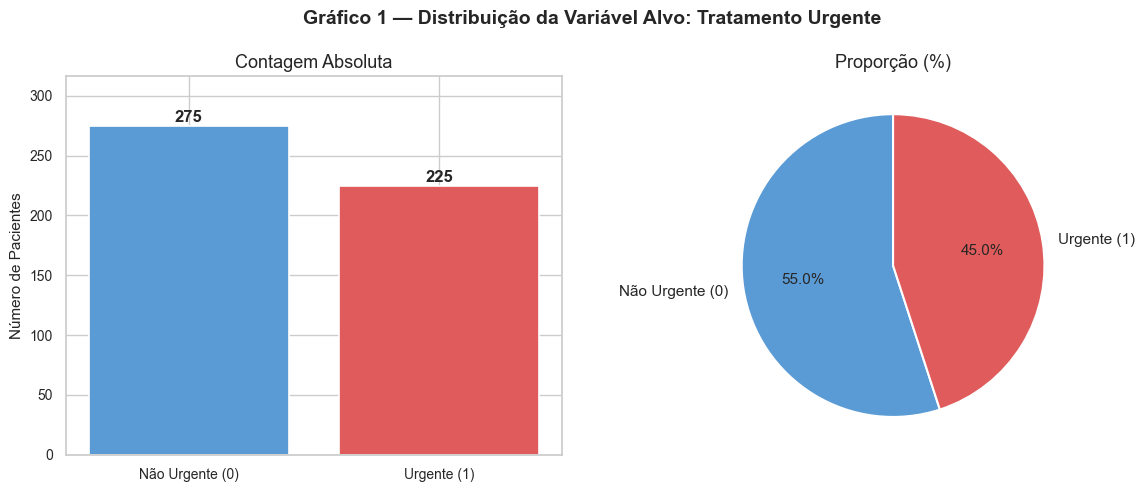


Total de pacientes: 500
Urgentes: 275 (55.0%)
Não urgentes: 225 (45.0%)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Gráfico 1 — Distribuição da Variável Alvo: Tratamento Urgente", fontsize=14, fontweight="bold")

# Contagem absoluta
contagem = df["tratamento_urgente"].value_counts()
labels = ["Não Urgente (0)", "Urgente (1)"]
cores = ["#5B9BD5", "#E05C5C"]

axes[0].bar(labels, contagem.values, color=cores, edgecolor="white", linewidth=1.2)
axes[0].set_title("Contagem Absoluta")
axes[0].set_ylabel("Número de Pacientes")
for i, v in enumerate(contagem.values):
    axes[0].text(i, v + 3, str(v), ha="center", fontweight="bold", fontsize=12)
axes[0].set_ylim(0, max(contagem.values) * 1.15)

# Proporção (pizza)
axes[1].pie(
    contagem.values,
    labels=labels,
    autopct="%1.1f%%",
    colors=cores,
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=1.5),
    textprops={"fontsize": 11}
)
axes[1].set_title("Proporção (%)")

plt.tight_layout()
plt.savefig("grafico1_variavel_alvo.png", bbox_inches="tight")
plt.show()

print(f"\nTotal de pacientes: {len(df)}")
print(f"Urgentes: {contagem[1]} ({contagem[1]/len(df)*100:.1f}%)")
print(f"Não urgentes: {contagem[0]} ({contagem[0]/len(df)*100:.1f}%)")

## 4. Distribuição de Idade por Urgência

> **Informação observada:** Distribuições relevantes para o problema | Comparações entre grupos

Analisar como a faixa etária se distribui entre pacientes urgentes e não urgentes revela se a ONG atende predominantemente crianças, adultos ou idosos com maior necessidade imediata.

/var/folders/tn/9h_sfkcs41x05ydn8985cs5c0000gn/T/ipykernel_6319/1367269555.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(dados_box, patch_artist=True, labels=["Não Urgente", "Urgente"],


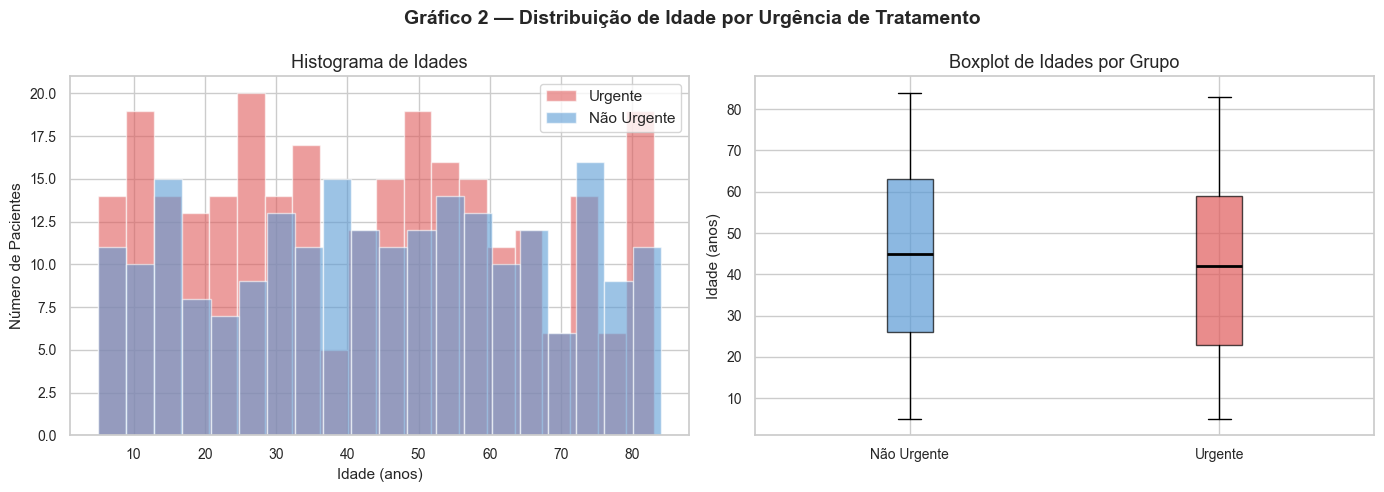

Estatísticas de idade por grupo:
                    count  mean   std  min   25%   50%   75%   max
tratamento_urgente                                                
0                   225.0  44.9  22.7  5.0  26.0  45.0  63.0  84.0
1                   275.0  42.0  22.6  5.0  23.0  42.0  59.0  83.0


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Gráfico 2 — Distribuição de Idade por Urgência de Tratamento", fontsize=14, fontweight="bold")

# Histograma com KDE separado por grupo
for label, cor, nome in [(1, "#E05C5C", "Urgente"), (0, "#5B9BD5", "Não Urgente")]:
    subset = df[df["tratamento_urgente"] == label]["idade"]
    axes[0].hist(subset, bins=20, alpha=0.6, color=cor, label=nome, edgecolor="white")

axes[0].set_title("Histograma de Idades")
axes[0].set_xlabel("Idade (anos)")
axes[0].set_ylabel("Número de Pacientes")
axes[0].legend()

# Boxplot por grupo
dados_box = [
    df[df["tratamento_urgente"] == 0]["idade"],
    df[df["tratamento_urgente"] == 1]["idade"]
]
bp = axes[1].boxplot(dados_box, patch_artist=True, labels=["Não Urgente", "Urgente"],
                      medianprops=dict(color="black", linewidth=2))
for patch, cor in zip(bp["boxes"], ["#5B9BD5", "#E05C5C"]):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)
axes[1].set_title("Boxplot de Idades por Grupo")
axes[1].set_ylabel("Idade (anos)")

plt.tight_layout()
plt.savefig("grafico2_idade_urgencia.png", bbox_inches="tight")
plt.show()

print("Estatísticas de idade por grupo:")
print(df.groupby("tratamento_urgente")["idade"].describe().round(1))

## 5. Mapa de Correlação entre Variáveis Numéricas

> **Informação observada:** Correlações entre variáveis

O mapa de calor (heatmap) permite identificar quais variáveis clínicas e comportamentais têm maior correlação com a urgência do tratamento, orientando a seleção de features para o modelo de Machine Learning.

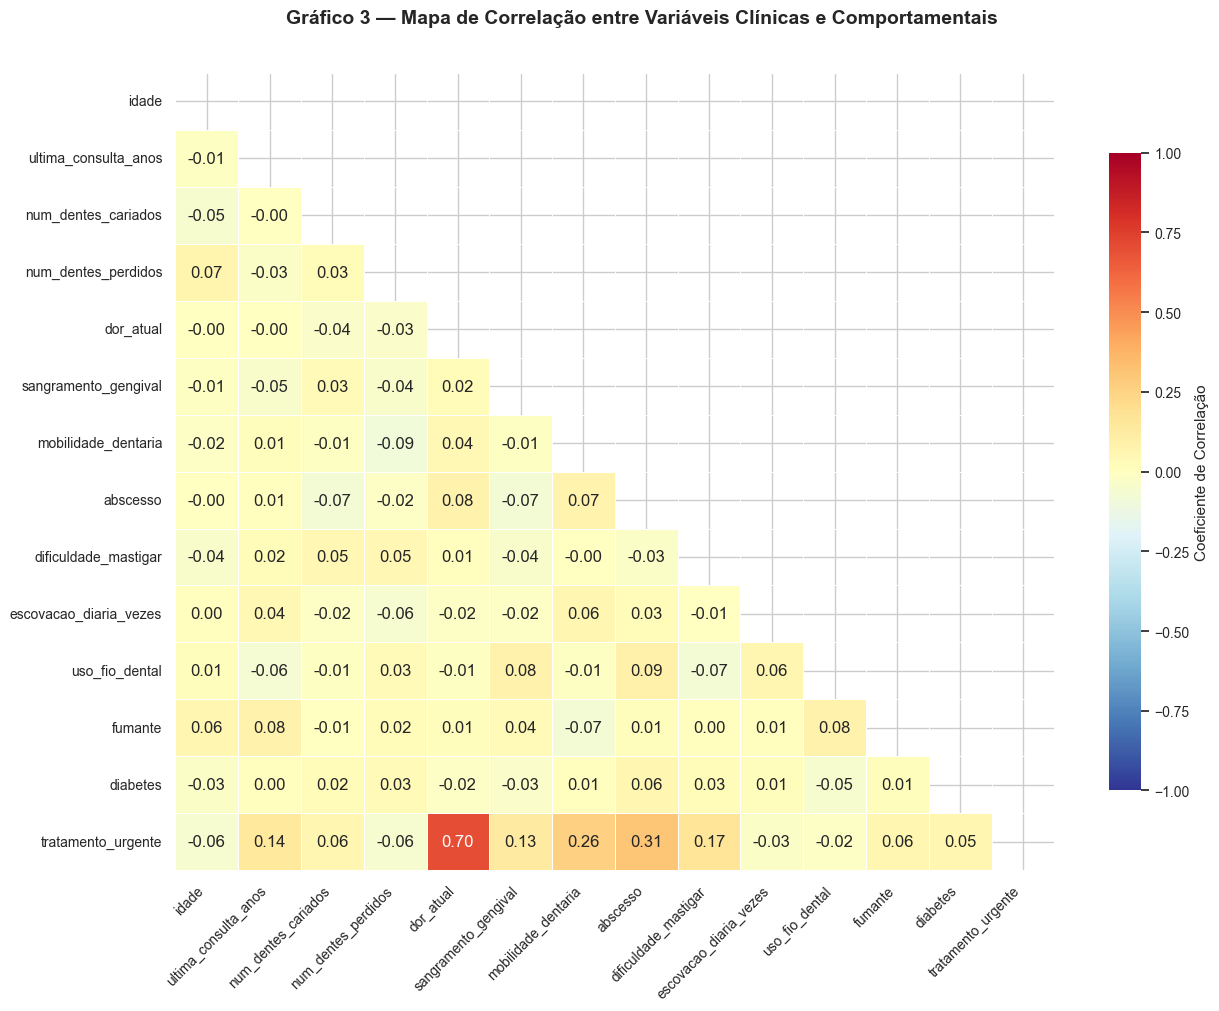


Correlações com 'tratamento_urgente' (ordenadas):
dor_atual                 0.698
abscesso                  0.305
mobilidade_dentaria       0.260
dificuldade_mastigar      0.168
ultima_consulta_anos      0.143
sangramento_gengival      0.127
fumante                   0.058
num_dentes_cariados       0.057
diabetes                  0.055
uso_fio_dental           -0.018
escovacao_diaria_vezes   -0.029
num_dentes_perdidos      -0.061
idade                    -0.062
Name: tratamento_urgente, dtype: float64


In [8]:
colunas_numericas = [
    "idade", "ultima_consulta_anos", "num_dentes_cariados", "num_dentes_perdidos",
    "dor_atual", "sangramento_gengival", "mobilidade_dentaria", "abscesso",
    "dificuldade_mastigar", "escovacao_diaria_vezes", "uso_fio_dental",
    "fumante", "diabetes", "tratamento_urgente"
]

corr = df[colunas_numericas].corr()

fig, ax = plt.subplots(figsize=(13, 10))
fig.suptitle("Gráfico 3 — Mapa de Correlação entre Variáveis Clínicas e Comportamentais",
             fontsize=14, fontweight="bold", y=1.01)

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlBu_r",
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor="white",
    cbar_kws={"shrink": 0.8, "label": "Coeficiente de Correlação"},
    ax=ax
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig("grafico3_correlacao.png", bbox_inches="tight")
plt.show()

print("\nCorrelações com 'tratamento_urgente' (ordenadas):")
print(corr["tratamento_urgente"].drop("tratamento_urgente").sort_values(ascending=False).round(3))

## 6. Proporção de Urgência por Fatores de Risco Clínico

> **Informação observada:** Comparações entre grupos | Estruturas, grupos ou outliers

Este gráfico compara a proporção de pacientes urgentes entre grupos com e sem fatores de risco (dor, abscesso, mobilidade dentária e sangramento gengival). Isso valida a relevância clínica das variáveis escolhidas para o modelo.

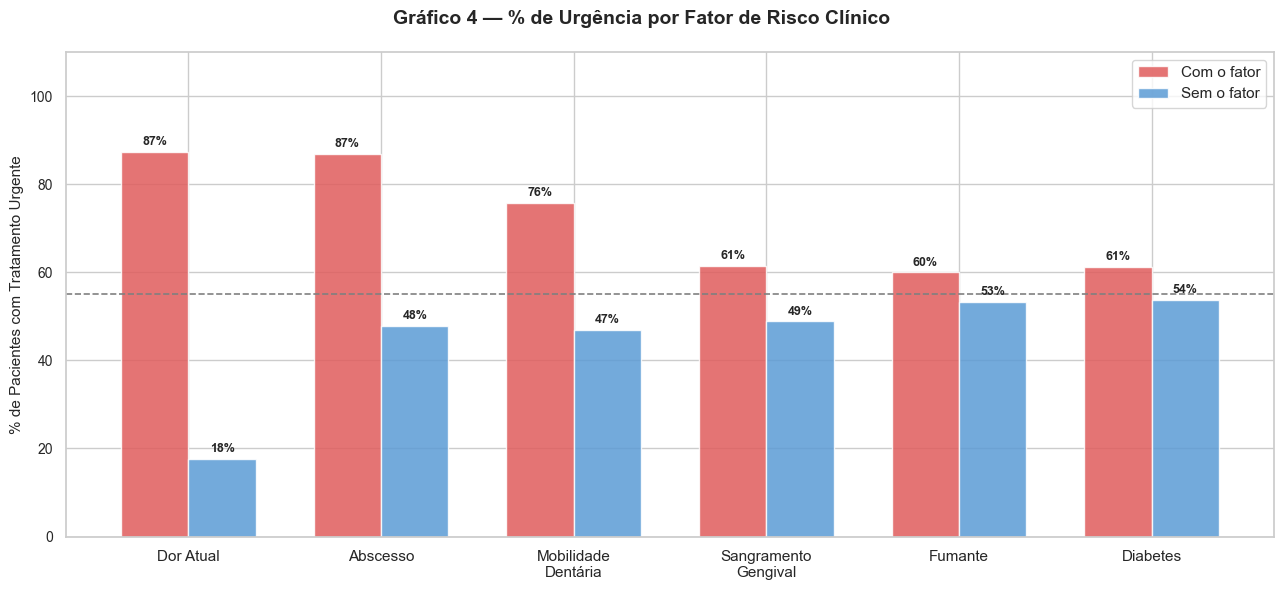

In [9]:
fatores = {
    "Dor Atual": "dor_atual",
    "Abscesso": "abscesso",
    "Mobilidade\nDentária": "mobilidade_dentaria",
    "Sangramento\nGengival": "sangramento_gengival",
    "Fumante": "fumante",
    "Diabetes": "diabetes"
}

urgencia_com = []
urgencia_sem = []
for nome, col in fatores.items():
    com = df[df[col] == 1]["tratamento_urgente"].mean() * 100
    sem = df[df[col] == 0]["tratamento_urgente"].mean() * 100
    urgencia_com.append(com)
    urgencia_sem.append(sem)

x = np.arange(len(fatores))
largura = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
fig.suptitle("Gráfico 4 — % de Urgência por Fator de Risco Clínico", fontsize=14, fontweight="bold")

barras_com = ax.bar(x - largura/2, urgencia_com, largura, label="Com o fator", color="#E05C5C", alpha=0.85, edgecolor="white")
barras_sem = ax.bar(x + largura/2, urgencia_sem, largura, label="Sem o fator", color="#5B9BD5", alpha=0.85, edgecolor="white")

ax.set_ylabel("% de Pacientes com Tratamento Urgente")
ax.set_xticks(x)
ax.set_xticklabels(fatores.keys(), fontsize=11)
ax.set_ylim(0, 110)
ax.legend(fontsize=11)
ax.axhline(y=df["tratamento_urgente"].mean()*100, color="gray", linestyle="--", linewidth=1.2, label="Média geral")

for bar in barras_com:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f"{bar.get_height():.0f}%", ha="center", fontsize=9, fontweight="bold")
for bar in barras_sem:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f"{bar.get_height():.0f}%", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("grafico4_fatores_risco.png", bbox_inches="tight")
plt.show()

## 7. Dispersão: Dentes Cariados vs. Dentes Perdidos

> **Informação observada:** Correlações entre variáveis | Estruturas, grupos ou outliers

O gráfico de dispersão entre número de dentes cariados e perdidos, colorido pela urgência, revela padrões e agrupamentos naturais nos dados — essencial para entender como o modelo de classificação poderá separar os dois grupos.

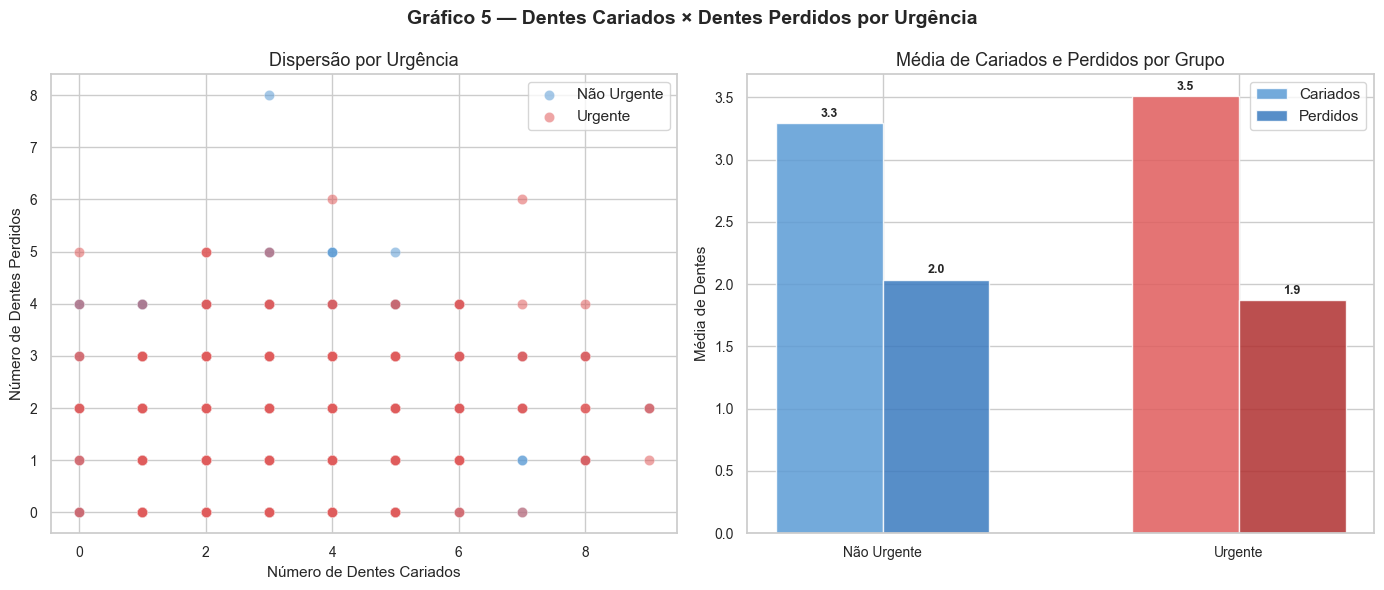

Médias por grupo:
                    num_dentes_cariados  num_dentes_perdidos
tratamento_urgente                                          
0                                  3.29                 2.04
1                                  3.51                 1.87


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Gráfico 5 — Dentes Cariados × Dentes Perdidos por Urgência", fontsize=14, fontweight="bold")

cores_map = {0: "#5B9BD5", 1: "#E05C5C"}
labels_map = {0: "Não Urgente", 1: "Urgente"}

# Scatter por urgência
for urgencia, grupo in df.groupby("tratamento_urgente"):
    axes[0].scatter(
        grupo["num_dentes_cariados"],
        grupo["num_dentes_perdidos"],
        c=cores_map[urgencia],
        label=labels_map[urgencia],
        alpha=0.55, edgecolors="white", linewidth=0.4, s=55
    )
axes[0].set_xlabel("Número de Dentes Cariados")
axes[0].set_ylabel("Número de Dentes Perdidos")
axes[0].set_title("Dispersão por Urgência")
axes[0].legend()

# Médias por grupo (barplot agrupado)
medias = df.groupby("tratamento_urgente")[["num_dentes_cariados", "num_dentes_perdidos"]].mean()
x_idx = np.arange(2)
larg = 0.3
axes[1].bar(x_idx - larg/2, medias["num_dentes_cariados"], larg,
            color=["#5B9BD5", "#E05C5C"], alpha=0.85, label="Cariados", edgecolor="white")
axes[1].bar(x_idx + larg/2, medias["num_dentes_perdidos"], larg,
            color=["#3A7ABF", "#B03030"], alpha=0.85, label="Perdidos", edgecolor="white")
axes[1].set_xticks(x_idx)
axes[1].set_xticklabels(["Não Urgente", "Urgente"])
axes[1].set_ylabel("Média de Dentes")
axes[1].set_title("Média de Cariados e Perdidos por Grupo")
axes[1].legend()
for i, (car, per) in enumerate(zip(medias["num_dentes_cariados"], medias["num_dentes_perdidos"])):
    axes[1].text(i - larg/2, car + 0.05, f"{car:.1f}", ha="center", fontsize=9, fontweight="bold")
    axes[1].text(i + larg/2, per + 0.05, f"{per:.1f}", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("grafico5_cariados_perdidos.png", bbox_inches="tight")
plt.show()

print("Médias por grupo:")
print(df.groupby("tratamento_urgente")[["num_dentes_cariados", "num_dentes_perdidos"]].mean().round(2))

## 8. Hábitos de Higiene Bucal e Urgência

> **Informação observada:** Padrões ou tendências | Comparações entre grupos

A frequência de escovação e uso de fio dental são indicadores de prevenção. Este gráfico investiga se pacientes com piores hábitos têm maior proporção de casos urgentes — apoiando ações educativas da ONG.

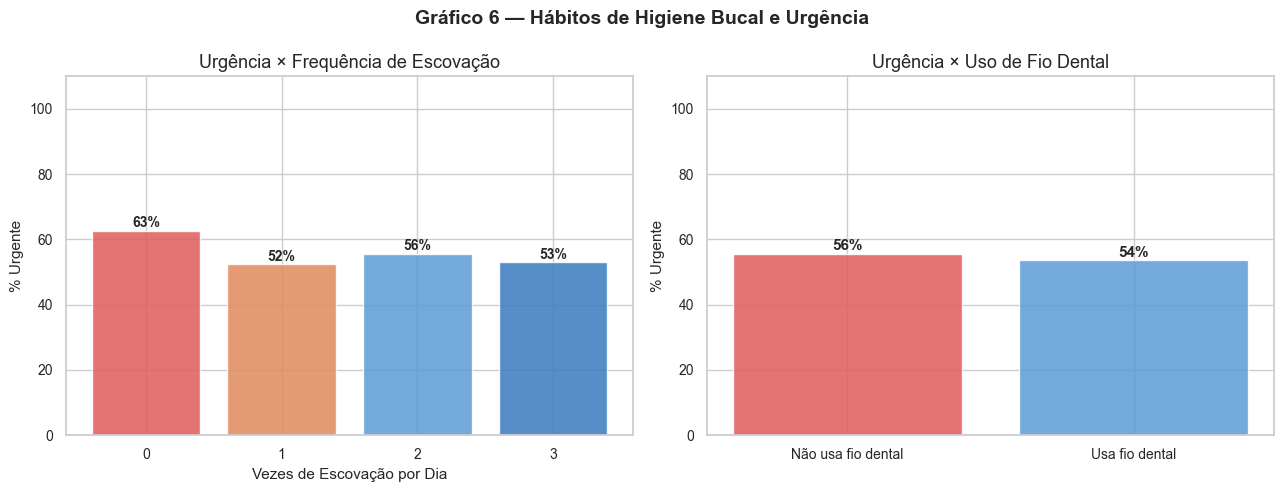

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Gráfico 6 — Hábitos de Higiene Bucal e Urgência", fontsize=14, fontweight="bold")

# Escovação
esc_urgencia = df.groupby("escovacao_diaria_vezes")["tratamento_urgente"].mean() * 100
axes[0].bar(esc_urgencia.index, esc_urgencia.values,
            color=["#E05C5C", "#E08A5C", "#5B9BD5", "#3A7ABF"],
            alpha=0.85, edgecolor="white")
axes[0].set_xlabel("Vezes de Escovação por Dia")
axes[0].set_ylabel("% Urgente")
axes[0].set_title("Urgência × Frequência de Escovação")
axes[0].set_xticks([0, 1, 2, 3])
for i, v in enumerate(esc_urgencia.values):
    axes[0].text(esc_urgencia.index[i], v + 1, f"{v:.0f}%", ha="center", fontweight="bold", fontsize=10)
axes[0].set_ylim(0, 110)

# Fio dental
fio_urgencia = df.groupby("uso_fio_dental")["tratamento_urgente"].mean() * 100
labels_fio = ["Não usa fio dental", "Usa fio dental"]
axes[1].bar(labels_fio, fio_urgencia.values, color=["#E05C5C", "#5B9BD5"], alpha=0.85, edgecolor="white")
axes[1].set_ylabel("% Urgente")
axes[1].set_title("Urgência × Uso de Fio Dental")
for i, v in enumerate(fio_urgencia.values):
    axes[1].text(i, v + 1, f"{v:.0f}%", ha="center", fontweight="bold", fontsize=11)
axes[1].set_ylim(0, 110)

plt.tight_layout()
plt.savefig("grafico6_higiene.png", bbox_inches="tight")
plt.show()

## 9. Urgência por Região da Cidade

> **Informação observada:** Comparações entre grupos | Padrões ou tendências

Identificar as regiões com maior proporção de casos urgentes permite à ONG planejar a escala dos dentistas voluntários e priorizar a abertura de novos postos de atendimento.

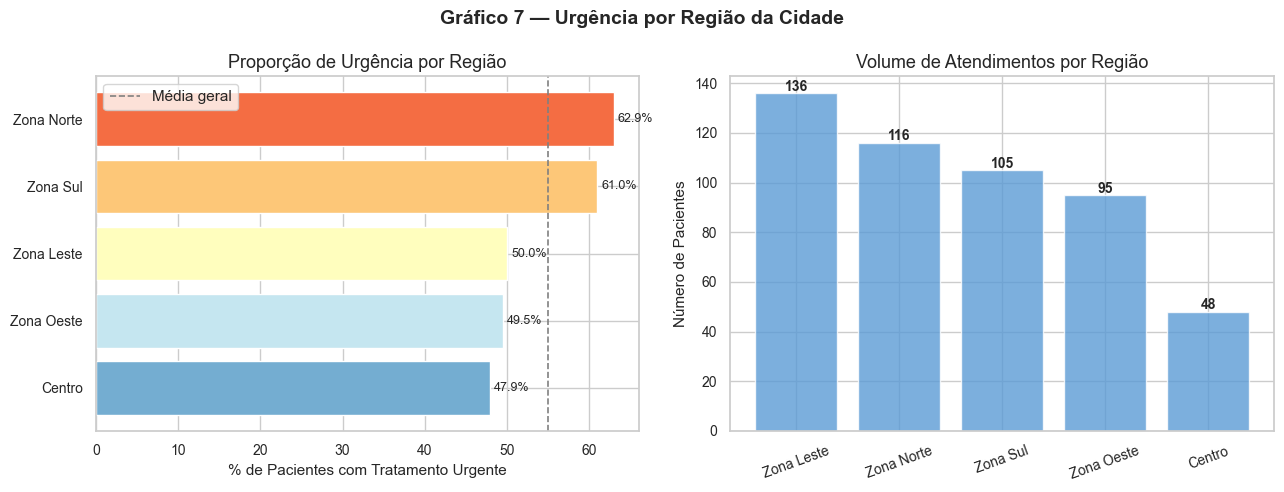

In [12]:
regiao_stats = df.groupby("regiao").agg(
    total=("tratamento_urgente", "count"),
    urgentes=("tratamento_urgente", "sum")
).reset_index()
regiao_stats["perc_urgente"] = regiao_stats["urgentes"] / regiao_stats["total"] * 100
regiao_stats = regiao_stats.sort_values("perc_urgente", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Gráfico 7 — Urgência por Região da Cidade", fontsize=14, fontweight="bold")

# % urgente por região
cores_regiao = plt.cm.RdYlBu_r(np.linspace(0.2, 0.8, len(regiao_stats)))
axes[0].barh(regiao_stats["regiao"], regiao_stats["perc_urgente"],
             color=cores_regiao, edgecolor="white")
axes[0].set_xlabel("% de Pacientes com Tratamento Urgente")
axes[0].set_title("Proporção de Urgência por Região")
axes[0].axvline(x=df["tratamento_urgente"].mean()*100, color="gray", linestyle="--", linewidth=1.2, label="Média geral")
axes[0].legend()
for i, row in regiao_stats.reset_index().iterrows():
    axes[0].text(row["perc_urgente"] + 0.5, i, f"{row['perc_urgente']:.1f}%", va="center", fontsize=9)

# Total de pacientes por região
regiao_total = df["regiao"].value_counts()
axes[1].bar(regiao_total.index, regiao_total.values, color="#5B9BD5", alpha=0.8, edgecolor="white")
axes[1].set_ylabel("Número de Pacientes")
axes[1].set_title("Volume de Atendimentos por Região")
axes[1].tick_params(axis="x", rotation=20)
for i, v in enumerate(regiao_total.values):
    axes[1].text(i, v + 1, str(v), ha="center", fontweight="bold", fontsize=10)

plt.tight_layout()
plt.savefig("grafico7_regiao.png", bbox_inches="tight")
plt.show()

## 10. Tendência: Tempo sem Consulta × Urgência

> **Informação observada:** Padrões ou tendências temporais

Quanto mais tempo o paciente fica sem atendimento odontológico, maior tende a ser a gravidade dos problemas. Este gráfico investiga essa tendência temporal, validando `ultima_consulta_anos` como uma variável preditora relevante.

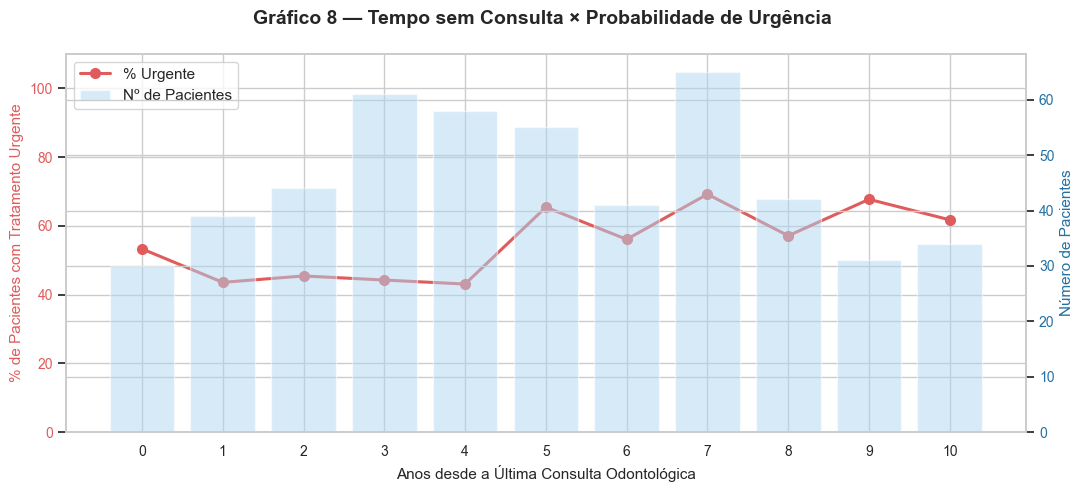

Proporção de urgência por anos sem consulta:
 ultima_consulta_anos  perc_urgente  count
                    0     53.333333     30
                    1     43.589744     39
                    2     45.454545     44
                    3     44.262295     61
                    4     43.103448     58
                    5     65.454545     55
                    6     56.097561     41
                    7     69.230769     65
                    8     57.142857     42
                    9     67.741935     31
                   10     61.764706     34


In [13]:
tendencia = df.groupby("ultima_consulta_anos")["tratamento_urgente"].agg(["mean", "count"]).reset_index()
tendencia["perc_urgente"] = tendencia["mean"] * 100

fig, ax1 = plt.subplots(figsize=(11, 5))
fig.suptitle("Gráfico 8 — Tempo sem Consulta × Probabilidade de Urgência", fontsize=14, fontweight="bold")

cor_linha = "#E05C5C"
cor_barra = "#AED6F1"

ax2 = ax1.twinx()
ax2.bar(tendencia["ultima_consulta_anos"], tendencia["count"],
        color=cor_barra, alpha=0.5, label="Nº de Pacientes")
ax2.set_ylabel("Número de Pacientes", color="#2471A3", fontsize=11)
ax2.tick_params(axis="y", labelcolor="#2471A3")

ax1.plot(tendencia["ultima_consulta_anos"], tendencia["perc_urgente"],
         "o-", color=cor_linha, linewidth=2.2, markersize=7, label="% Urgente", zorder=5)
ax1.set_xlabel("Anos desde a Última Consulta Odontológica")
ax1.set_ylabel("% de Pacientes com Tratamento Urgente", color=cor_linha, fontsize=11)
ax1.tick_params(axis="y", labelcolor=cor_linha)
ax1.set_xticks(tendencia["ultima_consulta_anos"])
ax1.set_ylim(0, 110)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.savefig("grafico8_tempo_consulta.png", bbox_inches="tight")
plt.show()

print("Proporção de urgência por anos sem consulta:")
print(tendencia[["ultima_consulta_anos", "perc_urgente", "count"]].to_string(index=False))

## 11. Resumo Estatístico por Grupo

Estatísticas descritivas comparando pacientes urgentes e não urgentes nas variáveis numéricas principais.

In [14]:
resumo = df.groupby("tratamento_urgente")[[
    "idade", "ultima_consulta_anos", "num_dentes_cariados",
    "num_dentes_perdidos", "escovacao_diaria_vezes"
]].describe().T.round(2)

print("Estatísticas por grupo (0=Não Urgente, 1=Urgente):")
resumo

Estatísticas por grupo (0=Não Urgente, 1=Urgente):


tratamento_urgente                 0       1
idade                  count  225.00  275.00
                       mean    44.86   42.01
                       std     22.70   22.64
                       min      5.00    5.00
                       25%     26.00   23.00
...                              ...     ...
escovacao_diaria_vezes min      0.00    0.00
                       25%      1.00    1.00
                       50%      2.00    2.00
                       75%      2.00    2.00
                       max      3.00    3.00

[40 rows x 2 columns]

---
## 12. Conclusões da EDA

Com base na análise exploratória realizada, destacam-se os seguintes achados relevantes para o modelo de ML:

1. **Dor atual e abscesso** são os fatores com maior correlação com urgência — pacientes com dor têm ~85% de probabilidade de serem urgentes.
2. **Tempo sem consulta** apresenta tendência positiva com a urgência: quanto mais anos sem ir ao dentista, maior a chance de necessitar de atendimento imediato.
3. **Hábitos de higiene bucal** (escovação e fio dental) mostram que pacientes com melhores hábitos têm menor proporção de casos urgentes, validando essas variáveis como features preventivas.
4. **Distribuição geográfica** indica que algumas regiões concentram mais casos urgentes, podendo orientar a alocação dos dentistas voluntários da ONG.
5. **Dentes cariados e perdidos** formam clusters visíveis que separam pacientes urgentes dos não urgentes no scatter plot.

### Variável Alvo
`tratamento_urgente` (binária: 0 = não urgente, 1 = urgente) — distribuição equilibrada (55% urgentes), favorável ao treinamento de classificadores como Regressão Logística, Árvore de Decisão ou Random Forest na Sprint 4.
